In [ ]:
!pip install scipy nibabel

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [ ]:
# import nibabel as nib
# import numpy as np
# # from scipy.ndimage import zoom

In [ ]:
# img = nib.load("/home/student24/nifti_reoriented/UPENN-GBM-00029/perfusion_brain_only.nii.gz")
# fourD_image = img.get_fdata()
# image_shape = fourD_image.shape[:3]

In [ ]:
# image_shape

(128, 128, 20)

In [ ]:
# mask_img = nib.load("/home/student24/region_masks/UPENN-GBM-00029/CSF_mask.nii.gz")
# mask = mask_img.get_fdata()
# mask_shape = mask.shape

In [ ]:
# print("Image shape:", image_shape)
# print("Mask shape:", mask_shape)

Image shape: (128, 128, 20)
Mask shape: (220, 220, 60)


In [ ]:
# zoom_factors = np.array(image_shape) / np.array(mask_shape)
# resampled_mask = zoom(mask, zoom=zoom_factors, order=0)
# print("Resampled mask shape:", resampled_mask.shape)

Resampled mask shape: (128, 128, 20)


In [ ]:
# # masked_voxels_over_time = []

# # for t in range(fourD_image.shape[3]):
# #     frame = fourD_image[:, :, :, t]
# #     masked_voxels = frame[resampled_mask > 0]
# #     masked_voxels_over_time.append(masked_voxels)

# # masked_voxels_over_time = np.array(masked_voxels_over_time)
# # print("Masked time series shape:", masked_voxels_over_time.shape)
# resampled_seg = resample_from_to(seg_img, func_3d_img, order=0)
# resampled_seg_data = resampled_seg.get_fdata().astype(int)

Masked time series shape: (45, 6092)


In [ ]:
import nibabel as nib
from nibabel.processing import resample_from_to
import numpy as np
import pandas as pd
from nilearn.image import resample_img

In [ ]:
seg_img = nib.load("/home/student24/Desikan_Segmentation/UPENN-GBM-00029/mri/aparc.DKTatlas+aseg.deep.mgz")
func_3d_img = nib.load("/home/student24/nifti_reoriented/UPENN-GBM-00029/first_volume.nii.gz")

In [ ]:
func_img = nib.load("/home/student24/nifti_reoriented/UPENN-GBM-00029/perfusion_brain_only.nii.gz")
FOURD = func_img.get_fdata()

In [ ]:
resampled_func_img.shape
dat = resampled_func_img.get_fdata()

In [ ]:
seg_img_d = seg_img.get_fdata().astype(int)
np.unique(seg_img_d)

array([   0,    2,   41, 1014, 1027, 1028, 2012, 2014, 2022, 2024, 2028])

In [ ]:
print("4D shape    :", func_img.shape)
print("4D affine   :", func_img.affine)
print("3D shape    :", resampled_seg_data.shape)
print("3D affine   :", resampled_seg.affine)

4D shape    : (128, 128, 20, 45)
4D affine   : [[ -1.71875      0.          -0.         114.06147766]
 [ -0.           1.71875     -0.         -84.04725647]
 [  0.           0.           3.          16.66930389]
 [  0.           0.           0.           1.        ]]
3D shape    : (128, 128, 20)
3D affine   : [[ -1.71875      0.           0.         114.06147766]
 [  0.           1.71875      0.         -84.04725647]
 [  0.           0.           3.          16.66930389]
 [  0.           0.           0.           1.        ]]


In [ ]:
resampled_func_img = resample_img(func_img, target_affine=seg_img.affine,
                                  target_shape=seg_img.shape, interpolation='continuous', force_resample =True)  # or 'nearest'

/tmp/ipykernel_489225/1363267975.py:1: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(func_img, target_affine=seg_img.affine,


In [ ]:
region_labels = {
    "rh_volume_superiorfrontal": 2028,
    "lh_volume_frontalpole": 1032,
    "lh_volume_rostralmiddlefrontal": 1027,
    "lh_volume_cuneus": 1005,
    "lh_volume_superiorfrontal": 1028,
    "rh_volume_precentral": 2024,
    "lh_volume_pericalcarine": 1021,
    "rh_volume_rostralmiddlefrontal": 2027,
    "rh_volume_cuneus": 2005,
    "rh_volume_caudalmiddlefrontal": 2003
}

In [ ]:
# # Create a dictionary to store time series for each region
# region_time_series = {}

# # Loop over each region and extract the time series
# for region_name, label_val in region_labels.items():
#     print(f"Processing region: {region_name} (Label {label_val})")

#     # Find voxel indices where segmentation equals the label
#     voxel_indices = np.where(seg_img_d == label_val)

#     # Get time series across all time points for those voxels
#     voxel_time_series = dat[voxel_indices[0], voxel_indices[1], voxel_indices[2], :]

#     # Average time series across voxels in the region
#     mean_time_series = voxel_time_series.mean(axis=0)

#     # Store in dictionary
#     region_time_series[region_name] = mean_time_series

# # Convert to DataFrame and save as CSV
# df = pd.DataFrame(region_time_series)
# df.to_csv("UPENN-GBM-00004_region_timeseries.csv", index=False)

# print("✅ Time series extracted and saved to region_time_series.csv")

Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)


/tmp/ipykernel_489225/1728731774.py:15: RuntimeWarning: Mean of empty slice.
  mean_time_series = voxel_time_series.mean(axis=0)
/home/student24/jupyter-env/lib/python3.11/site-packages/numpy/_core/_methods.py:137: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
Processing region: lh_volume_pericalcarine (Label 1021)
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
Processing region: rh_volume_cuneus (Label 2005)
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
✅ Time series extracted and saved to region_time_series.csv


In [ ]:
try:
        resampled_func_img, seg_img = resample_functional_to_segmentation(func_path, seg_path)
        extract_region_timeseries_from_images(resampled_func_img, seg_img, output_csv, region_labels)
    except Exception as e:
        print(f"Error processing {subject_id}: {e}")

### FINAL EXTRACTION FUNCTIONS

####  Resample Functional Image to Segmentation Space

In [ ]:
def resample_functional_to_segmentation(func_4d_path, seg_path):
    import nibabel as nib
    from nilearn.image import resample_img

    func_img = nib.load(func_4d_path)
    seg_img = nib.load(seg_path)

    resampled_func_img = resample_img(
        func_img,
        target_affine=seg_img.affine,
        target_shape=seg_img.shape,
        interpolation='continuous',
        force_resample=True
    )

    return resampled_func_img, seg_img

#### Extract Region Time Series and Save CSV

In [ ]:
def extract_region_timeseries_from_images(resampled_func_img, seg_img, output_csv_path, region_labels):
    import numpy as np
    import pandas as pd

    func_data = resampled_func_img.get_fdata()
    seg_data = seg_img.get_fdata().astype(int)

    region_time_series = {}

    for region_name, label_val in region_labels.items():
        print(f"Processing region: {region_name} (Label {label_val})")

        voxel_indices = np.where(seg_data == label_val)

        if voxel_indices[0].size == 0:
            print(f"No voxels found for region {region_name}. Skipping.")
            continue

        voxel_time_series = func_data[voxel_indices[0], voxel_indices[1], voxel_indices[2], :]
        mean_time_series = voxel_time_series.mean(axis=0)
        region_time_series[region_name] = mean_time_series

    df = pd.DataFrame(region_time_series)
    df.to_csv(output_csv_path, index=False)
    print(f" Time series extracted and saved to {output_csv_path}")

#### The loop to process multiple subjects (GLIOBLASTOMA)

In [ ]:
import os

subjects = ["UPENN-GBM-00004", #"UPENN-GBM-00029",
   # "UPENN-GBM-00054",
    # "UPENN-GBM-00071",
    # "UPENN-GBM-00125",
    "UPENN-GBM-00143",
    "UPENN-GBM-00174",
   # "UPENN-GBM-00249",
    "UPENN-GBM-00322",
    # "UPENN-GBM-00365",
    # "UPENN-GBM-00416",
    # "UPENN-GBM-00444",
    "UPENN-GBM-00459",
    "UPENN-GBM-00473",
    "UPENN-GBM-00519",
    #"UPENN-GBM-00564",
    "UPENN-GBM-00567",
    "UPENN-GBM-00618",
    "UPENN-GBM-00619",
    #"UPENN-GBM-00620"
]


seg_base = "/home/student24/Desikan_Segmentation"
func_base = "/home/student24/nifti_reoriented"
output_base = "/home/student24/region_timeseries_output"

os.makedirs(output_base, exist_ok=True)

region_labels = {
    "rh_volume_superiorfrontal": 2028,
    "lh_volume_frontalpole": 1032,
    "lh_volume_rostralmiddlefrontal": 1027,
    "lh_volume_cuneus": 1005,
    "lh_volume_superiorfrontal": 1028,
    "rh_volume_precentral": 2024,
    "lh_volume_pericalcarine": 1021,
    "rh_volume_rostralmiddlefrontal": 2027,
    "rh_volume_cuneus": 2005,
    "rh_volume_caudalmiddlefrontal": 2003
}


for subject_id in subjects:
    print(f"\n Processing subject: {subject_id}")

    func_path = os.path.join(func_base, subject_id, "perfusion_brain_only.nii.gz")
    seg_path = os.path.join(seg_base, subject_id, "mri", "aparc.DKTatlas+aseg.deep.mgz")
    output_csv = os.path.join(output_base, f"{subject_id}_region_timeseries.csv")

    try:
        resampled_func_img, seg_img = resample_functional_to_segmentation(func_path, seg_path)
        extract_region_timeseries_from_images(resampled_func_img, seg_img, output_csv, region_labels)
    except Exception as e:
        print(f"Error processing {subject_id}: {e}")


 Processing subject: UPENN-GBM-00004


/tmp/ipykernel_489225/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
No voxels found for region lh_volume_rostralmiddlefrontal. Skipping.
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
No voxels found for region lh_volume_superiorfrontal. Skipping.
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Proc

/tmp/ipykernel_489225/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels found for region rh_volume_caudalmiddlefrontal. Skipping.
 Time series extracted and saved to /home/student24/region_timeser

...

Processing region: rh_volume_superiorfrontal (Label 2028)
No voxels found for region rh_volume_superiorfrontal. Skipping.
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
No voxels found for region lh_volume_rostralmiddlefrontal. Skipping.
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
No voxels found for region lh_volume_superiorfrontal. Skipping.
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2

/tmp/ipykernel_489225/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
No voxels found for region lh_volume_superiorfrontal. Skipping.
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels f

/tmp/ipykernel_489225/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
 Time series extracted and saved to /home/student24/region_timeseries_output/UPENN-GBM-00620_region_timeseries.csv


In [ ]:
,


In [ ]:
import os

subjects = [ "sub-001",
    "sub-002",
    "sub-004",
    "sub-005",
    "sub-007",
    "sub-009",
    "sub-010",
    "sub-012",
    "sub-014",
    "sub-018",
    "sub-022",
    "sub-029",
    "sub-050",
    "sub-051",
    "sub-053",
    "sub-066",
    "sub-081",
    "sub-083",
    "sub-085",
     "sub-098"
    ]


seg_base = "/home/student24/Desikan_Segmentation_controls"
func_base = "/home/student24/nifti_reoriented_controls"
output_base = "/home/student24/region_timeseries_output_controls"

os.makedirs(output_base, exist_ok=True)

region_labels = {
    "rh_volume_superiorfrontal": 2028,
    "lh_volume_frontalpole": 1032,
    "lh_volume_rostralmiddlefrontal": 1027,
    "lh_volume_cuneus": 1005,
    "lh_volume_superiorfrontal": 1028,
    "rh_volume_precentral": 2024,
    "lh_volume_pericalcarine": 1021,
    "rh_volume_rostralmiddlefrontal": 2027,
    "rh_volume_cuneus": 2005,
    "rh_volume_caudalmiddlefrontal": 2003
}


for subject_id in subjects:
    print(f"\n Processing subject: {subject_id}")

    func_path = os.path.join(func_base, subject_id, "bold_brain_only.nii.gz")
    seg_path = os.path.join(seg_base, subject_id, "mri", "aparc.DKTatlas+aseg.deep.mgz")
    output_csv = os.path.join(output_base, f"{subject_id}_region_timeseries_cont.csv")

    try:
        resampled_func_img, seg_img = resample_functional_to_segmentation(func_path, seg_path)
        extract_region_timeseries_from_images(resampled_func_img, seg_img, output_csv, region_labels)
    except Exception as e:
        print(f"Error processing {subject_id}: {e}")


 Processing subject: sub-050


/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels found for region rh_volume_caudalmiddlefrontal. Skipping.
 Time series extracted and saved to /home/student24/region_timeseries_output_controls/sub-050_region_timeseries_cont.csv

 Processing s

/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels found for region rh_volume_caudalmiddlefrontal. Skipping.
 Time series extracted and saved to /home/student24/region_timeseries_output

...

Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels found for region rh_volume_caudalmiddlefrontal. Skipping.
 Time series extracted and saved to /home/student24/region_timeseries_output_controls/sub-083_region_timeseries_cont.csv

 Processing s

/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels found for region rh_volume_caudalmiddlefrontal. Skipping.
 Time series extracted and saved to /home/student24/region_timeseries_output

/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels found for region rh_volume_caudalmiddlefrontal. Skipping.
 Time series extracted and saved to /home/student24/region_timeseries_output_controls/sub-098_region_timeseries_cont.csv


In [ ]:
import nibabel as nib
import matplotlib.pyplot as plt

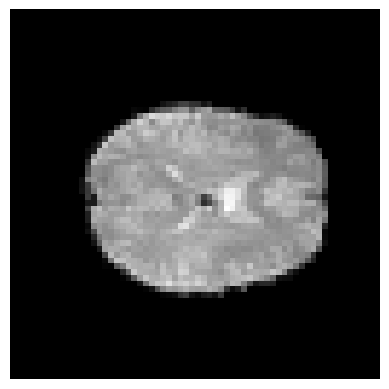

In [ ]:
img = nib.load('/home/student24/nifti_reoriented_controls/sub-085/brain_mask.nii.gz')
data = img.get_fdata()

plt.imshow(data[:, :, data.shape[2] // 2], cmap='gray')
plt.axis('off')
plt.show()

In [ ]:
import os

subjects = ["UPENN-GBM-00004", #"UPENN-GBM-00029",
   # "UPENN-GBM-00054",
    # "UPENN-GBM-00071",
    # "UPENN-GBM-00125",
    "UPENN-GBM-00143",
    "UPENN-GBM-00174",
   # "UPENN-GBM-00249",
    "UPENN-GBM-00322",
    # "UPENN-GBM-00365",
    # "UPENN-GBM-00416",
    # "UPENN-GBM-00444",
    "UPENN-GBM-00459",
    "UPENN-GBM-00473",
    #"UPENN-GBM-00519",
    #"UPENN-GBM-00564",
    "UPENN-GBM-00567",
    "UPENN-GBM-00618",
    "UPENN-GBM-00619"
    #"UPENN-GBM-00620"
]


seg_base = "/home/student24/Desikan_Segmentation"
func_base = "/home/student24/nifti_reoriented"
output_base = "/home/student24/region_timeseries_output"

os.makedirs(output_base, exist_ok=True)

region_labels = {
    "rh_volume_superiorfrontal": 2028,
    "lh_volume_frontalpole": 1032,
    "lh_volume_rostralmiddlefrontal": 1027,
    "lh_volume_cuneus": 1005,
    "lh_volume_superiorfrontal": 1028,
    "rh_volume_precentral": 2024,
    "lh_volume_pericalcarine": 1021,
    "rh_volume_rostralmiddlefrontal": 2027,
    "rh_volume_cuneus": 2005,
    "rh_volume_caudalmiddlefrontal": 2003
}


for subject_id in subjects:
    print(f"\n Processing subject: {subject_id}")

    func_path = os.path.join(func_base, subject_id, "perfusion_brain_only.nii.gz")
    seg_path = os.path.join(seg_base, subject_id, "mri", "aparc.DKTatlas+aseg.deep.mgz")
    output_csv = os.path.join(output_base, f"{subject_id}_region_timeseries.csv")

    try:
        resampled_func_img, seg_img = resample_functional_to_segmentation(func_path, seg_path)
        extract_region_timeseries_from_images(resampled_func_img, seg_img, output_csv, region_labels)
    except Exception as e:
        print(f"Error processing {subject_id}: {e}")


 Processing subject: UPENN-GBM-00004


/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
No voxels found for region lh_volume_rostralmiddlefrontal. Skipping.
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
No voxels found for region lh_volume_superiorfrontal. Skipping.
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Proc

/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
No voxels found for region rh_volume_superiorfrontal. Skipping.
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
No voxels found for region lh_volume_rostralmiddlefrontal. Skipping.
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
No voxels found for region lh_volume_superiorfrontal. Skipping.
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2

...

Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels found for region rh_volume_caudalmiddlefrontal. Skipping.
 Time s

/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
No voxels found for region rh_volume_superiorfrontal. Skipping.
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
No voxels found for region lh_volume_rostralmiddlefrontal. Skipping.
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
No voxels found for region lh_volume_superiorfrontal. Skipping.
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2

/tmp/ipykernel_5932/2110820735.py:8: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  resampled_func_img = resample_img(


Processing region: rh_volume_superiorfrontal (Label 2028)
Processing region: lh_volume_frontalpole (Label 1032)
No voxels found for region lh_volume_frontalpole. Skipping.
Processing region: lh_volume_rostralmiddlefrontal (Label 1027)
Processing region: lh_volume_cuneus (Label 1005)
No voxels found for region lh_volume_cuneus. Skipping.
Processing region: lh_volume_superiorfrontal (Label 1028)
No voxels found for region lh_volume_superiorfrontal. Skipping.
Processing region: rh_volume_precentral (Label 2024)
No voxels found for region rh_volume_precentral. Skipping.
Processing region: lh_volume_pericalcarine (Label 1021)
No voxels found for region lh_volume_pericalcarine. Skipping.
Processing region: rh_volume_rostralmiddlefrontal (Label 2027)
No voxels found for region rh_volume_rostralmiddlefrontal. Skipping.
Processing region: rh_volume_cuneus (Label 2005)
No voxels found for region rh_volume_cuneus. Skipping.
Processing region: rh_volume_caudalmiddlefrontal (Label 2003)
No voxels f

In [ ]:
import nibabel as nib
import numpy as np
import pandas as pd
import scipy.stats
from scipy.ndimage import zoom
import os

In [ ]:
image_path = "/home/student24/nifti_reoriented/UPENN-GBM-00029/perfusion_brain_only.nii.gz"
mask_dir = "/home/student24/region_masks/UPENN-GBM-00029"
region_names = ["3rd_ventricle", "4th_ventricle", "CSF",  "left_lateral_ventricle", "left_putamen",  "right_lateral_ventricle", "right_pallidum", "right_putamen"]
output_csv = "UPENN-GBM-00029_timeseries_features.csv"

In [ ]:
# ---- Load 4D Image ----
img = nib.load(image_path)
fourD_image = img.get_fdata()
image_shape = fourD_image.shape[:3]
timepoints = fourD_image.shape[3]

In [ ]:
def extract_features(time_series):
    return {
        'mean': np.mean(time_series),
        'std': np.std(time_series),
        'skewness': scipy.stats.skew(time_series),
        'kurtosis': scipy.stats.kurtosis(time_series),
        'tsnr': np.mean(time_series) / np.std(time_series) if np.std(time_series) != 0 else 0,
        'slope': np.polyfit(range(len(time_series)), time_series, 1)[0],
        'fft_power': np.sum(np.abs(np.fft.fft(time_series))**2)
    }
    return features

In [ ]:
# # ---- Process Each Region ----
# all_features = []

# for region in region_names:
#     mask_path = os.path.join(mask_dir, f"{region}_mask.nii.gz")
#     mask = nib.load(mask_path).get_fdata()

#     # Resample to match image shape if needed
#     mask_shape = mask.shape
#     if mask_shape != image_shape:
#         zoom_factors = np.array(image_shape) / np.array(mask_shape)
#         mask = zoom(mask, zoom=zoom_factors, order=0)

#     # ---- Extract masked voxels over time ----
#     masked_voxels_over_time = []
#     for t in range(timepoints):
#         frame = fourD_image[:, :, :, t]
#         masked_voxels = frame[mask > 0]
#         masked_voxels_over_time.append(masked_voxels)

#     # Convert to array
#     masked_voxels_over_time = np.array(masked_voxels_over_time)
#     print(f"masked_voxels_over_time shape for {region}: {masked_voxels_over_time.shape} (time x voxels)")

#   # Transpose to (voxels x time)
#     masked_data = masked_voxels_over_time.T
#     raw_ts_filename = f"{region}_raw_time_series.csv"
#     save_raw_time_series(masked_data, region, raw_ts_filename)
#     print(f"masked_data shape for {region}: {masked_data.shape} (voxels x time)")

#     # ---- Extract features per voxel ----
#     for i, ts in enumerate(masked_data):
#         feat = extract_features(ts)
#         feat['voxel_index'] = i
#         feat['region'] = region
#         all_features.append(feat)
#         print(f"Voxel {i+1} in {region} - mean: {feat['mean']:.3f}, std: {feat['std']:.3f}, tsnr: {feat['tsnr']:.3f}")

# # ---- Save as DataFrame ----
# df = pd.DataFrame(all_features)
# df.to_csv(output_csv, index=False)
# print(f"\n Saved extracted time-series features to: {output_csv}")


In [ ]:
def save_raw_time_series(masked_data, region, output_file):
    """
    masked_data: numpy array of shape (voxels x time)
    region: string, name of the brain region
    output_file: csv filename to save raw time series data
    """
    rows = []
    n_voxels = masked_data.shape[0]
    n_timepoints = masked_data.shape[1]

    for i in range(n_voxels):
        ts = masked_data[i, :]
        row = {"region": region, "voxel_index": i}
        for t in range(n_timepoints):
            row[f"t{t}"] = ts[t]
        rows.append(row)

    df = pd.DataFrame(rows)
    df.to_csv(output_file, index=False)
    print(f"Raw time series data saved for {region} to {output_file}")


In [ ]:
image_path = "/home/student24/nifti_reoriented/UPENN-GBM-00029/perfusion_brain_only.nii.gz"
mask_dir = "/home/student24/region_masks/UPENN-GBM-00029"
region_names = ["CSF", "Frontal", "Temporal", "Occipital", "Parietal", "Cerebellum", "Thalamus", "BasalGanglia"]

features = process_image_with_masks(image_path, mask_dir, region_names)

df = pd.DataFrame([features])
df.to_csv("UPENN-GBM-00029_features.csv", index=False)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
from sklearn.svm import SVC

In [ ]:

X = df.values
y = [0]*len(healthy_subjects) + [1]*len(glioblastoma_subjects)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

preds = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))


In [ ]:

from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

df = pd.read_csv("all_subjects_features.csv")

X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_model.fit(X_train, y_train)

y_pred = svm_model.predict(X_test)


print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
import nibabel as nib
import numpy as np
import pandas as pd
import scipy.stats
from scipy.ndimage import zoom

# === STEP 1: Load 4D Image and 3D Mask ===
image_path = "/home/student24/nifti_reoriented/UPENN-GBM-00029/perfusion_brain_only.nii.gz"
mask_path = "/home/student24/region_masks/UPENN-GBM-00029/CSF_mask.nii.gz"

img = nib.load(image_path)
mask = nib.load(mask_path)

fourD_image = img.get_fdata()
mask_data = mask.get_fdata()

# === STEP 2: Resample mask to match image if shapes differ ===
if fourD_image.shape[:3] != mask_data.shape:
    zoom_factors = np.array(fourD_image.shape[:3]) / np.array(mask_data.shape)
    mask_data = zoom(mask_data, zoom=zoom_factors, order=0)  # Nearest-neighbor for masks

# === STEP 3: Extract summary features across all voxels at each time point ===
def extract_summary_features(voxel_values):
    return {
        'mean': np.mean(voxel_values),
        'std': np.std(voxel_values),
        'skewness': scipy.stats.skew(voxel_values),
        'kurtosis': scipy.stats.kurtosis(voxel_values),
        'tsnr': np.mean(voxel_values) / np.std(voxel_values) if np.std(voxel_values) != 0 else 0,
        'fft_power': np.sum(np.abs(np.fft.fft(voxel_values)) ** 2)
    }

summary_features = []

# Loop over time points
n_timepoints = fourD_image.shape[3]
for t in range(n_timepoints):
    frame = fourD_image[:, :, :, t]
    voxels = frame[mask_data > 0]

    if voxels.size > 0:
        features = extract_summary_features(voxels)
        features["timepoint"] = t  # Add time index
        summary_features.append(features)

# === STEP 4: Save as CSV ===
df = pd.DataFrame(summary_features)
df.to_csv("voxelwise_timepoint_features.csv", index=False)

print("✅ Feature extraction complete. Saved as voxelwise_timepoint_features.csv")


✅ Feature extraction complete. Saved as voxelwise_timepoint_features.csv
